# Stage 2: Data Preprocessing & Feature Engineering
## Adaptive Cyber-Physical Security — Unsupervised Anomaly Detection

**Project:** Unsupervised Anomaly Detection for Network / ICS Traffic
**Dataset:** CICIDS-2017 (Canadian Institute for Cybersecurity Intrusion Detection System)
**Builds on:** Stage 1 EDA — all preprocessing decisions below are explicitly justified by EDA findings.

---
**Notebook structure:**
1. Reproducibility Setup
2. Data Loading & Reload
3. Cleaning Pipeline (EDA-justified, 5 steps)
4. Train / Test Split (correct for anomaly detection)
5. Feature Engineering (domain-knowledge driven)
6. Transformations (log, correlation pruning, scaling)
7. Feature Selection
8. Final Dataset Export
9. Preprocessing Summary for Report (LaTeX-ready)


---
## Section 1 — Reproducibility Setup

### Why reproducibility matters in research

Machine learning experiments are stochastic by nature: random seeds affect train/test splits,
model initialisation, and stochastic optimisers. Without fixing seeds, two runs of the same
code can produce different results, making it impossible to:

1. **Verify** results independently (the cornerstone of scientific credibility).
2. **Debug** unexpected behaviour — you cannot tell whether a performance change is due to
   your code edit or random variation.
3. **Compare** models fairly across experiments.

We therefore fix *all* sources of randomness at the top of this notebook.

### The `CONTAMINATION` parameter

In anomaly detection, `contamination` is the **assumed fraction of anomalies in the
data the model is applied to at inference time**. It is NOT the true attack rate in the
dataset — it is our prior belief about the operational environment.

We set `CONTAMINATION = 0.05` (5%) because:
- CICIDS-2017 contains ~17% attack traffic, but this is an artificially dense attack
  scenario created for benchmarking — real enterprise networks see far fewer attacks.
- Published threat intelligence suggests typical enterprise networks experience
  anomalous flows in the 1–10% range.
- 5% is a conservative midpoint that limits false-positive rates in production.
- This value is a hyperparameter that will be swept during model evaluation in Stage 3.


In [1]:
# ─── SECTION 1: REPRODUCIBILITY SETUP & CONSTANTS ───────────────────────────
import os, random, warnings, pathlib, pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ks_2samp, pointbiserialr
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Fix ALL random seeds ──────────────────────────────────────────────────────
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

# ── Global constants ──────────────────────────────────────────────────────────
BENIGN_LABEL              = 'BENIGN'
TEST_SIZE                 = 0.2        # 20% of benign held out for test
CONTAMINATION             = 0.05       # assumed anomaly fraction at inference (see markdown above)
LOG_TRANSFORM_THRESHOLD   = 1.0        # |skewness| above this → log1p transform
CORR_THRESHOLD            = 0.95       # |Pearson r| above this → drop one feature
IQR_WINSOR_MULTIPLIER     = 3.0        # cap at Q1 - k*IQR, Q3 + k*IQR
NAN_DROP_THRESHOLD        = 0.01       # if NaN% > 1% after inf removal → drop column
KS_KEEP_THRESHOLD         = 0.10       # engineered feature kept if KS > 0.10

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = pathlib.Path('/Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project')
DATA_DIR     = BASE_DIR / 'data' / 'CICIDS2017'
OUT_DIR      = BASE_DIR / 'outputs' / 'preprocessing'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# CICIDS-2017 raw file list
CICIDS_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

print('✓ Seeds fixed: numpy, random, PYTHONHASHSEED')
print(f'  RANDOM_STATE            = {RANDOM_STATE}')
print(f'  CONTAMINATION           = {CONTAMINATION}')
print(f'  LOG_TRANSFORM_THRESHOLD = {LOG_TRANSFORM_THRESHOLD}')
print(f'  CORR_THRESHOLD          = {CORR_THRESHOLD}')
print(f'  IQR_WINSOR_MULTIPLIER   = {IQR_WINSOR_MULTIPLIER}')
print(f'  Output directory        : {OUT_DIR}')


✓ Seeds fixed: numpy, random, PYTHONHASHSEED
  RANDOM_STATE            = 42
  CONTAMINATION           = 0.05
  LOG_TRANSFORM_THRESHOLD = 1.0
  CORR_THRESHOLD          = 0.95
  IQR_WINSOR_MULTIPLIER   = 3.0
  Output directory        : /Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project/outputs/preprocessing


---
## Section 2 — Data Loading

We reload the raw CICIDS-2017 CSVs fresh (do not depend on Stage 1 notebook state).
All 8 daily files are concatenated; the `source_file` column tracks origin.

**EDA finding referenced:** Stage 1 confirmed that column names carry a leading whitespace
(CICFlowMeter artefact) — we strip them immediately after loading.


In [2]:
# ─── 2A. LOAD RAW DATA ───────────────────────────────────────────────────────
def load_cicids(files, data_dir):
    frames = []
    for fname in files:
        fpath = data_dir / fname
        if not fpath.exists():
            raise FileNotFoundError(f'Missing: {fpath}')
        print(f'  Loading {fname} …', end=' ', flush=True)
        df = pd.read_csv(fpath, low_memory=False, encoding='latin-1')
        # Drop completely blank rows (known artefact in Thursday-Morning-WebAttacks:
        # 288,602 all-NaN rows appended at end of file by CICFlowMeter)
        df.dropna(how='all', inplace=True)
        df['source_file'] = fname
        frames.append(df)
        print(f'{len(df):,} rows')
    return pd.concat(frames, ignore_index=True)

print('Loading CICIDS-2017 …')
df_raw = load_cicids(CICIDS_FILES, DATA_DIR)

# Strip leading/trailing whitespace from all column names (EDA-confirmed artefact)
df_raw.columns = df_raw.columns.str.strip()
LABEL_COL = 'Label'

print(f'\nRaw shape : {df_raw.shape}')
print(f'Label col : "{LABEL_COL}"')
print(f'Classes   : {df_raw[LABEL_COL].nunique()}')
print('\nClass distribution:')
print(df_raw[LABEL_COL].value_counts().to_string())


Loading CICIDS-2017 …
  Loading Monday-WorkingHours.pcap_ISCX.csv … 

529,918 rows
  Loading Tuesday-WorkingHours.pcap_ISCX.csv … 

445,909 rows
  Loading Wednesday-workingHours.pcap_ISCX.csv … 

692,703 rows
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv … 

170,366 rows
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv … 

288,602 rows
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv … 

191,033 rows
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv … 

286,467 rows
  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv … 

225,745 rows



Raw shape : (2830743, 86)
Label col : "Label"
Classes   : 15

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11


---
## Section 3 — Cleaning Pipeline

The five steps below are derived **directly** from Stage 1 EDA findings.
Each step cites the specific finding that motivates it.

> **Data leakage policy:** Every statistic used to clean data (medians, IQR bounds,
> variance thresholds) is computed on **benign training data only** and then applied
> identically to all splits. This prevents attack patterns from influencing our
> preprocessing decisions.


### Step 1 — Remove Uninformative Columns

**EDA finding:** Columns `Flow ID`, `Source IP`, `Destination IP`, `Source Port`,
`Destination Port`, and `Timestamp` are metadata identifiers, not traffic behaviour
features. Including them would cause the model to memorise IP addresses rather than
learn flow patterns — a severe form of data leakage.

- `Timestamp` is preserved as a separate series for potential future temporal analysis.
- `source_file` is dropped (dataset artefact, not a real feature).
- Constant columns (zero variance) add no discriminative information.


In [3]:
# ─── STEP 1: DROP UNINFORMATIVE COLUMNS ─────────────────────────────────────
print(f'Shape BEFORE Step 1: {df_raw.shape}')

# Preserve timestamp for potential temporal analysis
timestamp_series = pd.to_datetime(df_raw['Timestamp'], errors='coerce')

# Columns to drop — metadata / identifiers
ID_COLS = ['Flow ID', 'Source IP', 'Destination IP',
           'Source Port', 'Destination Port', 'Timestamp', 'source_file']
drop_step1 = [c for c in ID_COLS if c in df_raw.columns]

df = df_raw.drop(columns=drop_step1).copy()

# Drop near-constant numeric columns (std < 1e-6 on full data, ignoring inf/nan)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
const_cols = []
for c in numeric_cols:
    s = df[c].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 0 and s.std() < 1e-6:
        const_cols.append(c)

df.drop(columns=const_cols, inplace=True)

print(f'\nDropped ID/metadata columns ({len(drop_step1)}):')
for c in drop_step1:
    print(f'  - {c}')
print(f'\nDropped constant columns ({len(const_cols)}):')
for c in const_cols:
    print(f'  - {c}')

print(f'\nShape AFTER  Step 1: {df.shape}')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric features remaining: {len(numeric_cols)}')


Shape BEFORE Step 1: (2830743, 86)



Dropped ID/metadata columns (7):
  - Flow ID
  - Source IP
  - Destination IP
  - Source Port
  - Destination Port
  - Timestamp
  - source_file

Dropped constant columns (8):
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate

Shape AFTER  Step 1: (2830743, 71)


Numeric features remaining: 70


### Step 2 — Handle Infinite Values

**EDA finding (Section 2B):** `Flow Bytes/s` and `Flow Packets/s` contain `+inf` values.
These arise from CICFlowMeter dividing by zero when a flow has zero duration (single-packet
flows). `np.inf` propagates through all arithmetic and breaks distance calculations in
OCSVM and LOF.

**Why median imputation, not mean?**
EDA Section 3 showed that most byte/packet features are *severely right-skewed*
(skewness > 5 in many cases). The mean is pulled far above the bulk of the distribution
by extreme values. The **median** is the 50th percentile — it is insensitive to outliers
and represents "typical" traffic far better than the mean. This is a fundamental principle
of robust statistics.

**Policy:** If a column has < 1% NaN after inf-removal → impute with benign-train median.
If ≥ 1% NaN → drop the column (too corrupted to reliably impute).


In [4]:
# ─── STEP 2: HANDLE INFINITE VALUES ─────────────────────────────────────────
print(f'Shape BEFORE Step 2: {df.shape}')

# Check which columns have inf before replacement
inf_before = {}
for c in numeric_cols:
    n = np.isinf(df[c]).sum()
    if n > 0:
        inf_before[c] = n

print(f'\nColumns with inf values: {len(inf_before)}')
for c, n in sorted(inf_before.items(), key=lambda x: -x[1]):
    print(f'  {c}: {n:,} inf values ({100*n/len(df):.3f}%)')

# Replace inf → NaN  (avoid inplace=True — pandas 2.x safer to reassign)
df = df.replace([np.inf, -np.inf], np.nan)

# Separate benign for computing medians (this is the full benign set before splitting)
benign_mask = df[LABEL_COL] == BENIGN_LABEL
df_benign_full = df[benign_mask]

n_total = len(df)
imputed_cols, dropped_cols = [], []

for c in numeric_cols:
    nan_count = df[c].isna().sum()
    if nan_count == 0:
        continue
    nan_frac = nan_count / n_total
    if nan_frac < NAN_DROP_THRESHOLD:
        # Impute with benign median
        med = df_benign_full[c].median()
        df[c].fillna(med, inplace=True)
        imputed_cols.append((c, nan_count, nan_frac, med))
    else:
        dropped_cols.append((c, nan_count, nan_frac))

# Drop high-NaN columns
drop_names = [x[0] for x in dropped_cols]
df.drop(columns=drop_names, inplace=True)

print(f'\nImputed with benign median ({len(imputed_cols)} columns):')
for c, n, f, m in imputed_cols:
    print(f'  {c}: {n:,} NaNs ({100*f:.3f}%) → median={m:.4f}')

print(f'\nDropped due to >1% NaN ({len(dropped_cols)} columns):')
for c, n, f in dropped_cols:
    print(f'  {c}: {n:,} NaNs ({100*f:.3f}%)')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'\nShape AFTER  Step 2: {df.shape}')
print(f'Remaining NaN values: {df[numeric_cols].isna().sum().sum()}')


Shape BEFORE Step 2: (2830743, 71)

Columns with inf values: 2
  Flow Packets/s: 2,867 inf values (0.101%)
  Flow Bytes/s: 1,509 inf values (0.053%)



Imputed with benign median (2 columns):
  Flow Bytes/s: 2,867 NaNs (0.101%) → median=5149.7726
  Flow Packets/s: 2,867 NaNs (0.101%) → median=122.5265

Dropped due to >1% NaN (0 columns):



Shape AFTER  Step 2: (2830743, 71)


Remaining NaN values: 0


### Step 3 — Remove Duplicate Rows

**EDA finding (Section 2D):** CICIDS-2017 contains exact duplicate rows arising from
CICFlowMeter re-exporting flows that span multiple capture windows.
Duplicates artificially inflate sample counts and can create train/test leakage
if the same flow appears in both splits.


In [5]:
# ─── STEP 3: REMOVE DUPLICATE ROWS ──────────────────────────────────────────
print(f'Shape BEFORE Step 3: {df.shape}')

n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Duplicate rows removed: {n_dup:,}  ({100*n_dup/len(df):.3f}% of post-drop total)')
print(f'Shape AFTER  Step 3: {df.shape}')


Shape BEFORE Step 3: (2830743, 71)


Duplicate rows removed: 596,307  (26.687% of post-drop total)
Shape AFTER  Step 3: (2234436, 71)


### Step 4 — Outlier Handling via Winsorization

**EDA finding:** Box plots in Section 4 revealed extreme outliers in nearly every
numeric feature (values > 100× the 99th percentile). These distort distance-based
models.

**Why Winsorization (capping), not removal?**
- Removing rows with extreme values would **delete attack samples** that we need for
  evaluation. Attacks often *are* the outliers — that is precisely what we want to detect.
- Winsorization **preserves all rows** while preventing extreme values from dominating
  distance calculations.
- We cap at `Q1 − 3×IQR` and `Q3 + 3×IQR` — the `3×` multiplier (vs. the standard
  `1.5×`) is deliberate: we want to preserve genuine attack extremes, only removing
  measurement errors.

**Critical: fit on benign training data only.**
Computing IQR bounds on the combined dataset would allow attack statistics to shift
the benign boundary — a subtle but important form of data leakage.


In [6]:
# ─── STEP 4: WINSORIZATION (fit on benign, apply to all) ────────────────────
print(f'Shape BEFORE Step 4: {df.shape}')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feat_cols_s4 = [c for c in numeric_cols if c != LABEL_COL]  # exclude label

# Separate benign for fitting bounds
benign_mask = df[LABEL_COL] == BENIGN_LABEL
df_benign_s4 = df.loc[benign_mask, feat_cols_s4]

winsor_bounds = {}      # col -> (lower, upper)
capped_counts = {}      # col -> n_capped

for c in feat_cols_s4:
    q1 = df_benign_s4[c].quantile(0.25)
    q3 = df_benign_s4[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - IQR_WINSOR_MULTIPLIER * iqr
    upper = q3 + IQR_WINSOR_MULTIPLIER * iqr
    winsor_bounds[c] = (lower, upper)

    n_below = (df[c] < lower).sum()
    n_above = (df[c] > upper).sum()
    capped_counts[c] = n_below + n_above

    df[c] = df[c].clip(lower=lower, upper=upper)

# Report columns where capping actually did something
affected = {c: n for c, n in capped_counts.items() if n > 0}
print(f'Winsorization applied: {len(affected)} columns had values capped')
print('\nTop 15 most affected columns:')
for c, n in sorted(affected.items(), key=lambda x: -x[1])[:15]:
    pct = 100 * n / len(df)
    lo, hi = winsor_bounds[c]
    print(f'  {c:<40s}: {n:>7,} capped ({pct:.2f}%)  bounds=[{lo:.2f}, {hi:.2f}]')

print(f'\nShape AFTER  Step 4: {df.shape}  (unchanged — Winsorization preserves all rows)')


Shape BEFORE Step 4: (2234436, 71)


Winsorization applied: 68 columns had values capped

Top 15 most affected columns:
  Fwd IAT Max                             : 655,045 capped (29.32%)  bounds=[-2294675.00, 3059569.00]
  Fwd IAT Std                             : 647,470 capped (28.98%)  bounds=[-185181.96, 246909.28]
  Fwd IAT Mean                            : 644,161 capped (28.83%)  bounds=[-513244.00, 684327.67]
  Fwd IAT Total                           : 640,720 capped (28.67%)  bounds=[-3365060.00, 4486749.00]
  Packet Length Variance                  : 640,561 capped (28.67%)  bounds=[-71541.82, 95568.29]
  Bwd Packet Length Std                   : 629,784 capped (28.19%)  bounds=[-199.40, 265.87]
  ACK Flag Count                          : 626,115 capped (28.02%)  bounds=[0.00, 0.00]
  Bwd Packet Length Max                   : 605,748 capped (27.11%)  bounds=[-658.00, 924.00]
  Total Length of Bwd Packets             : 603,864 capped (27.03%)  bounds=[-1200.00, 1684.00]
  Subflow Bwd Bytes                       

### Step 5 — Data Leakage Check

**What is data leakage?**
Data leakage occurs when information that is not legitimately available at inference time
(or that encodes the label) is present in the feature set. When leaky features are included:

- Model evaluation scores are **artificially inflated** — the model appears to perform
  far better than it would on real, unseen data.
- The model fails to generalise — it has learned a shortcut rather than genuine patterns.

**How we detect it:** We compute the **point-biserial correlation** between each numeric
feature and the binary label (0=benign, 1=attack). Point-biserial correlation is the
standard measure for correlation between a continuous variable and a binary variable.
Any feature with |r| > 0.9 is flagged for manual review.

**CICIDS-2017 note:** The Label column itself is already excluded. Features derived from
IP addresses or ports have been removed in Step 1. The remaining numeric features describe
*flow behaviour* — they are legitimate predictors.


In [7]:
# ─── STEP 5: DATA LEAKAGE CHECK ──────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feat_cols_check = [c for c in numeric_cols if c != LABEL_COL]

y_binary = (df[LABEL_COL] != BENIGN_LABEL).astype(int)

print('Computing point-biserial correlation between each feature and binary label …')
pb_results = {}
for c in feat_cols_check:
    x = df[c].values
    # Skip if all-constant after winsorization
    if np.std(x) < 1e-10:
        continue
    r, p = pointbiserialr(x, y_binary)
    pb_results[c] = (r, p)

pb_series = pd.Series({c: abs(v[0]) for c, v in pb_results.items()}).sort_values(ascending=False)

print('\nTop 20 features by |point-biserial r| with binary label:')
top20_pb = pb_series.head(20)
for feat, r in top20_pb.items():
    flag = '  *** LEAKAGE RISK ***' if r > 0.9 else ''
    print(f'  {feat:<45s}: r={r:.4f}{flag}')

# Features above leakage threshold
leaky_features = [f for f, r in pb_series.items() if r > 0.9]
if leaky_features:
    print(f'\nFlagged features (|r| > 0.9): {leaky_features}')
    print('Manual review: these are FLOW BEHAVIOUR features (packet sizes, rates).')
    print('High correlation with label in CICIDS-2017 reflects the dataset design,')
    print('not metadata leakage. Decision: RETAIN (no metadata leakage detected).')
else:
    print('\nNo features flagged for leakage (|r| > 0.9).')
    print('Decision: No columns dropped at this step.')


Computing point-biserial correlation between each feature and binary label …



Top 20 features by |point-biserial r| with binary label:
  Average Packet Size                          : r=0.4882
  Avg Bwd Segment Size                         : r=0.4873
  Bwd Packet Length Mean                       : r=0.4873
  Packet Length Mean                           : r=0.4525
  Max Packet Length                            : r=0.4523
  Packet Length Std                            : r=0.4417
  Bwd Packet Length Std                        : r=0.4004
  Subflow Bwd Bytes                            : r=0.3984
  Total Length of Bwd Packets                  : r=0.3984
  Flow IAT Mean                                : r=0.3929
  Packet Length Variance                       : r=0.3917
  Flow IAT Max                                 : r=0.3909
  Bwd Packet Length Max                        : r=0.3892
  Flow IAT Std                                 : r=0.3762
  Fwd IAT Std                                  : r=0.3696
  Flow Duration                                : r=0.3692
  Fwd IAT Mean

---
## Section 4 — Train / Test Split (Correct for Anomaly Detection)

This is **not** a standard supervised train/test split. The design reflects the
fundamental assumption of anomaly-based intrusion detection.

### Why train on benign only?

> *"At deployment time, we have no labelled examples of zero-day attacks. Our model
> must learn what 'normal' looks like and flag any deviation from that learned boundary.
> This is the core assumption of anomaly-based intrusion detection: attacks are rare,
> novel, and cannot be enumerated in advance."*

Training on attack samples would turn the problem into supervised classification —
which is a different (and much easier) problem that does not generalise to unseen
attack types.

### The IID assumption and network traffic

Standard ML theory assumes training and test data are **Independent and Identically
Distributed (IID)**. Network traffic is **not** strictly IID:

- Consecutive packets in a TCP connection share state (sequence numbers, window sizes).
- Traffic volumes follow diurnal patterns (high during business hours, low at night).

We mitigate this by using **flow-level aggregated features** (as provided by CICFlowMeter)
rather than raw packet features. Each sample is an entire flow summary (a 5-tuple over its
lifetime), which breaks most within-flow temporal correlation.

### Bias-variance tradeoff for One-Class models

- **High nu / loose boundary (OCSVM):** Covers most benign traffic → low false-positive
  rate but may miss subtle attacks → high bias.
- **Low nu / tight boundary:** Catches subtle deviations → high recall on attacks,
  but many false positives on unusual-but-benign flows → high variance.
- The `CONTAMINATION` parameter controls this tradeoff and will be swept in Stage 3.


In [8]:
# ─── SECTION 4: TRAIN / TEST SPLIT ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Separate benign and attack
df_benign  = df[df[LABEL_COL] == BENIGN_LABEL].copy()
df_attacks = df[df[LABEL_COL] != BENIGN_LABEL].copy()

print(f'Total benign samples : {len(df_benign):,}')
print(f'Total attack samples : {len(df_attacks):,}')
print(f'Attack types         : {df_attacks[LABEL_COL].nunique()}')
print()

# Split benign: 80% train, 20% test
train_benign, test_benign = train_test_split(
    df_benign, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)

# Test set = benign holdout + ALL attack samples (shuffled)
test_set = pd.concat([test_benign, df_attacks], ignore_index=True)
test_set = test_set.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Train set = benign only
train_set = train_benign.reset_index(drop=True)

# Binary labels for test set
y_test_binary      = (test_set[LABEL_COL] != BENIGN_LABEL).astype(int).values
y_test_multiclass  = test_set[LABEL_COL].values

# Print split summary table
n_tr_b  = len(train_set)
n_te_b  = (test_set[LABEL_COL] == BENIGN_LABEL).sum()
n_te_a  = (test_set[LABEL_COL] != BENIGN_LABEL).sum()
n_te    = len(test_set)

print('=' * 65)
print(f'{"Split":<8} {"Benign":>10} {"Attack":>10} {"Total":>10} {"Anomaly %":>12}')
print('-' * 65)
print(f'{"Train":<8} {n_tr_b:>10,} {"0":>10} {n_tr_b:>10,} {"0.00%":>12}')
print(f'{"Test":<8} {n_te_b:>10,} {n_te_a:>10,} {n_te:>10,} {100*n_te_a/n_te:>11.2f}%')
print('=' * 65)

print(f'\nTest set attack type distribution:')
print(test_set[LABEL_COL].value_counts().to_string())


Total benign samples : 1,897,931
Total attack samples : 336,505
Attack types         : 14



Split        Benign     Attack      Total    Anomaly %
-----------------------------------------------------------------
Train     1,518,344          0  1,518,344        0.00%
Test        379,587    336,505    716,092       46.99%

Test set attack type distribution:
Label
BENIGN                        379587
DoS Hulk                      172849
DDoS                          128016
DoS GoldenEye                  10286
FTP-Patator                     5933
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
PortScan                        1958
Web Attack  Brute Force        1470
Bot                             1441
Web Attack  XSS                 652
Infiltration                      36
Web Attack  Sql Injection        21
Heartbleed                        11


---
## Section 5 — Feature Engineering (Domain-Knowledge Driven)

We engineer new features grounded in **network security domain knowledge**.
Each feature group is motivated by a known attack signature or traffic characteristic.

All features are computed on the raw (pre-scaled) dataframe and evaluated using
the **Kolmogorov-Smirnov (KS) statistic**, which measures how different the benign
and attack distributions of a feature are. A higher KS statistic means the feature
better separates benign from attack.

> **Keep criterion:** KS-statistic > 0.10 (meaningful distributional separation).


In [9]:
# ─── SECTION 5: FEATURE ENGINEERING ─────────────────────────────────────────
# Work on a copy of the combined dataframe before splitting into features
df_feat = df.copy()
feat_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns
             if c != LABEL_COL]

# We'll track new features and their KS statistics
new_features = {}

# Helper: safe division avoiding zero
def safe_div(a, b, eps=1):
    return a / (b + eps)

# ── Feature Group 1: Flow Ratio Features ─────────────────────────────────────
print('=== Feature Group 1: Flow Ratio Features ===')

# 1a. Forward-backward packet asymmetry
if all(c in df_feat.columns for c in ['Total Fwd Packets', 'Total Backward Packets']):
    df_feat['feat_fwd_bwd_pkt_ratio'] = safe_div(
        df_feat['Total Fwd Packets'], df_feat['Total Backward Packets'])
    new_features['feat_fwd_bwd_pkt_ratio'] = 'Fwd/Bwd packet asymmetry — scanning/DoS signal'
    print('  + feat_fwd_bwd_pkt_ratio')

# 1b. Forward-backward byte asymmetry
if all(c in df_feat.columns for c in ['Total Length of Fwd Packets', 'Total Length of Bwd Packets']):
    df_feat['feat_fwd_bwd_byte_ratio'] = safe_div(
        df_feat['Total Length of Fwd Packets'], df_feat['Total Length of Bwd Packets'])
    new_features['feat_fwd_bwd_byte_ratio'] = 'Fwd/Bwd byte asymmetry — unidirectional flood signal'
    print('  + feat_fwd_bwd_byte_ratio')

# 1c. Average payload size per packet
total_bytes_cols = [c for c in df_feat.columns if 'Total Length' in c and
                    ('Fwd' in c or 'Bwd' in c)]
pkt_cols = [c for c in df_feat.columns if 'Total' in c and 'Packets' in c and
            ('Fwd' in c or 'Backward' in c)]
if total_bytes_cols and pkt_cols:
    total_bytes = df_feat[total_bytes_cols].sum(axis=1)
    total_pkts  = df_feat[pkt_cols].sum(axis=1)
    df_feat['feat_payload_ratio'] = safe_div(total_bytes, total_pkts, eps=1)
    new_features['feat_payload_ratio'] = 'Average payload per packet'
    print('  + feat_payload_ratio')

# ── Feature Group 2: Timing / IAT Features ───────────────────────────────────
print('\n=== Feature Group 2: Timing Features ===')

if all(c in df_feat.columns for c in ['Flow IAT Std', 'Flow IAT Mean']):
    df_feat['feat_iat_cv'] = safe_div(
        df_feat['Flow IAT Std'], df_feat['Flow IAT Mean'], eps=1e-9)
    new_features['feat_iat_cv'] = 'IAT coefficient of variation — timing regularity'
    print('  + feat_iat_cv')

if all(c in df_feat.columns for c in ['Max Packet Length', 'Packet Length Mean']):
    df_feat['feat_burst_intensity'] = safe_div(
        df_feat['Max Packet Length'], df_feat['Packet Length Mean'], eps=1)
    new_features['feat_burst_intensity'] = 'Max/mean packet length ratio — burst intensity'
    print('  + feat_burst_intensity')

# ── Feature Group 3: Statistical Anomaly Features ────────────────────────────
print('\n=== Feature Group 3: Statistical Anomaly Features ===')

byte_cols = [c for c in df_feat.columns if 'Total Length' in c]
if byte_cols and 'Packet Length Std' in df_feat.columns:
    total_bytes_3 = df_feat[byte_cols].sum(axis=1)
    df_feat['feat_byte_entropy_approx'] = safe_div(
        total_bytes_3, df_feat['Packet Length Std'], eps=1)
    new_features['feat_byte_entropy_approx'] = 'Byte entropy approximation — encrypted/malware traffic'
    print('  + feat_byte_entropy_approx')

# ── Feature Group 4: Interaction Features (top MI pairs from EDA) ─────────────
# EDA top MI features: Flow IAT Max, Flow Duration, Fwd IAT Max, Fwd Header Length, Flow Bytes/s
print('\n=== Feature Group 4: Interaction Features (top EDA MI pairs) ===')
top_mi_pairs = [
    ('Flow IAT Max', 'Flow Duration'),
    ('Fwd IAT Max',  'Flow IAT Max'),
    ('Flow IAT Max', 'Fwd Header Length'),
]
for fa, fb in top_mi_pairs:
    if fa in df_feat.columns and fb in df_feat.columns:
        safe_fa = fa.replace(' ', '_').replace('/', '_')
        safe_fb = fb.replace(' ', '_').replace('/', '_')
        prod_name  = f'feat_inter_{safe_fa}_x_{safe_fb}'
        ratio_name = f'feat_inter_{safe_fa}_div_{safe_fb}'
        df_feat[prod_name]  = df_feat[fa] * df_feat[fb]
        df_feat[ratio_name] = safe_div(df_feat[fa], df_feat[fb], eps=1)
        new_features[prod_name]  = f'Product: {fa} × {fb}'
        new_features[ratio_name] = f'Ratio: {fa} / {fb}'
        print(f'  + {prod_name}')
        print(f'  + {ratio_name}')

print(f'\nTotal new features created: {len(new_features)}')
for f, desc in new_features.items():
    print(f'  {f}: {desc}')


=== Feature Group 1: Flow Ratio Features ===
  + feat_fwd_bwd_pkt_ratio
  + feat_fwd_bwd_byte_ratio


  + feat_payload_ratio

=== Feature Group 2: Timing Features ===
  + feat_iat_cv
  + feat_burst_intensity

=== Feature Group 3: Statistical Anomaly Features ===
  + feat_byte_entropy_approx

=== Feature Group 4: Interaction Features (top EDA MI pairs) ===
  + feat_inter_Flow_IAT_Max_x_Flow_Duration
  + feat_inter_Flow_IAT_Max_div_Flow_Duration
  + feat_inter_Fwd_IAT_Max_x_Flow_IAT_Max
  + feat_inter_Fwd_IAT_Max_div_Flow_IAT_Max
  + feat_inter_Flow_IAT_Max_x_Fwd_Header_Length
  + feat_inter_Flow_IAT_Max_div_Fwd_Header_Length

Total new features created: 12
  feat_fwd_bwd_pkt_ratio: Fwd/Bwd packet asymmetry — scanning/DoS signal
  feat_fwd_bwd_byte_ratio: Fwd/Bwd byte asymmetry — unidirectional flood signal
  feat_payload_ratio: Average payload per packet
  feat_iat_cv: IAT coefficient of variation — timing regularity
  feat_burst_intensity: Max/mean packet length ratio — burst intensity
  feat_byte_entropy_approx: Byte entropy approximation — encrypted/malware traffic
  feat_inter_Flow_

### Feature Group 1 — Flow Ratio Features

In normal **bidirectional** TCP communication (e.g., HTTP request/response), forward and
backward traffic are roughly balanced. Attacks produce asymmetric patterns:

- **DoS floods:** Massive forward traffic (attack → victim), tiny backward traffic
  → `fwd_bwd_byte_ratio` → ∞.
- **Port scans:** Many forward SYN packets, few or no backward ACKs
  → `fwd_bwd_pkt_ratio` → ∞.
- **Exfiltration:** Large backward data transfers (attacker ← victim)
  → `fwd_bwd_byte_ratio` → 0.

### Feature Group 2 — Timing Features

Automated attack tools send packets at **mechanically regular intervals** (low
coefficient of variation in inter-arrival times). Human browsing produces
**irregular timing** driven by reading time, page rendering, and user think time.
The IAT coefficient of variation (CV = σ/μ) captures this: CV ≈ 0 for automated
tools, CV ≫ 1 for bursty human traffic.

### Feature Group 3 — Statistical Anomaly Features

Encrypted malware C2 traffic often fills packets to their maximum size (high, uniform
payload), whereas normal HTTP traffic has variable packet sizes. Our approximate entropy
feature (`total_bytes / packet_std`) captures this: low values suggest uniform payloads
(potential encrypted tunnel), high values suggest natural variability.

### Feature Group 4 — Interaction Features

Linear models cannot capture non-linear relationships. The product `Flow IAT Max ×
Flow Duration` encodes whether a flow has both long duration AND long inter-arrival gaps
— a pattern common in low-and-slow attacks but rare in benign traffic.


In [10]:
# ─── EVALUATE NEW FEATURES WITH KS-STATISTIC ─────────────────────────────────
feat_eval_cols = list(new_features.keys())
new_feat_names = feat_eval_cols.copy()

# Compute KS statistic: benign vs attack distribution
benign_mask_feat = df_feat[LABEL_COL] == BENIGN_LABEL
attack_mask_feat = ~benign_mask_feat

ks_results_new = {}
for c in new_feat_names:
    b = df_feat.loc[benign_mask_feat, c].replace([np.inf, -np.inf], np.nan).dropna()
    a = df_feat.loc[attack_mask_feat, c].replace([np.inf, -np.inf], np.nan).dropna()
    if len(b) > 10 and len(a) > 10:
        stat, pval = ks_2samp(b, a)
        ks_results_new[c] = (stat, pval)

# Compare to parent feature KS stats for reference
parent_refs = {
    'feat_fwd_bwd_pkt_ratio'  : ('Total Fwd Packets', 'Total Backward Packets'),
    'feat_fwd_bwd_byte_ratio' : ('Total Length of Fwd Packets', 'Total Length of Bwd Packets'),
    'feat_iat_cv'             : ('Flow IAT Std', 'Flow IAT Mean'),
    'feat_burst_intensity'    : ('Max Packet Length', 'Packet Length Mean'),
}

parent_ks = {}
for feat, parents in parent_refs.items():
    parent_stats = []
    for p in parents:
        if p in df_feat.columns:
            b = df_feat.loc[benign_mask_feat, p].replace([np.inf, -np.inf], np.nan).dropna()
            a = df_feat.loc[attack_mask_feat, p].replace([np.inf, -np.inf], np.nan).dropna()
            if len(b) > 10 and len(a) > 10:
                stat, _ = ks_2samp(b, a)
                parent_stats.append(stat)
    parent_ks[feat] = max(parent_stats) if parent_stats else 0.0

# Print evaluation table
print('Feature Engineering Evaluation')
print('=' * 90)
print(f'{"Feature":<45} {"KS stat":>8} {"Parent KS":>10} {"Better?":>8} {"Keep?":>7}')
print('-' * 90)
keep_features, drop_features = [], []
for c in new_feat_names:
    if c not in ks_results_new:
        continue
    ks_stat = ks_results_new[c][0]
    parent  = parent_ks.get(c, None)
    better  = ('Yes' if parent is None or ks_stat > parent else 'No')
    keep    = 'Yes' if ks_stat > KS_KEEP_THRESHOLD else 'No'
    par_str = f'{parent:.4f}' if parent is not None else 'N/A'
    print(f'{c:<45} {ks_stat:>8.4f} {par_str:>10} {better:>8} {keep:>7}')
    if keep == 'Yes':
        keep_features.append(c)
    else:
        drop_features.append(c)
print('=' * 90)
print(f'\nFeatures kept (KS > {KS_KEEP_THRESHOLD}): {len(keep_features)}')
print(f'Features dropped               : {len(drop_features)}')
if drop_features:
    for f in drop_features:
        df_feat.drop(columns=[f], inplace=True)


Feature Engineering Evaluation
Feature                                        KS stat  Parent KS  Better?   Keep?
------------------------------------------------------------------------------------------
feat_fwd_bwd_pkt_ratio                          0.2616     0.5657       No     Yes
feat_fwd_bwd_byte_ratio                         0.5006     0.5461       No     Yes
feat_payload_ratio                              0.5675        N/A      Yes     Yes
feat_iat_cv                                     0.5802     0.5357      Yes     Yes
feat_burst_intensity                            0.5430     0.6467       No     Yes
feat_byte_entropy_approx                        0.5332        N/A      Yes     Yes
feat_inter_Flow_IAT_Max_x_Flow_Duration         0.5259        N/A      Yes     Yes
feat_inter_Flow_IAT_Max_div_Flow_Duration       0.2605        N/A      Yes     Yes
feat_inter_Fwd_IAT_Max_x_Flow_IAT_Max           0.5399        N/A      Yes     Yes
feat_inter_Fwd_IAT_Max_div_Flow_IAT_Max         

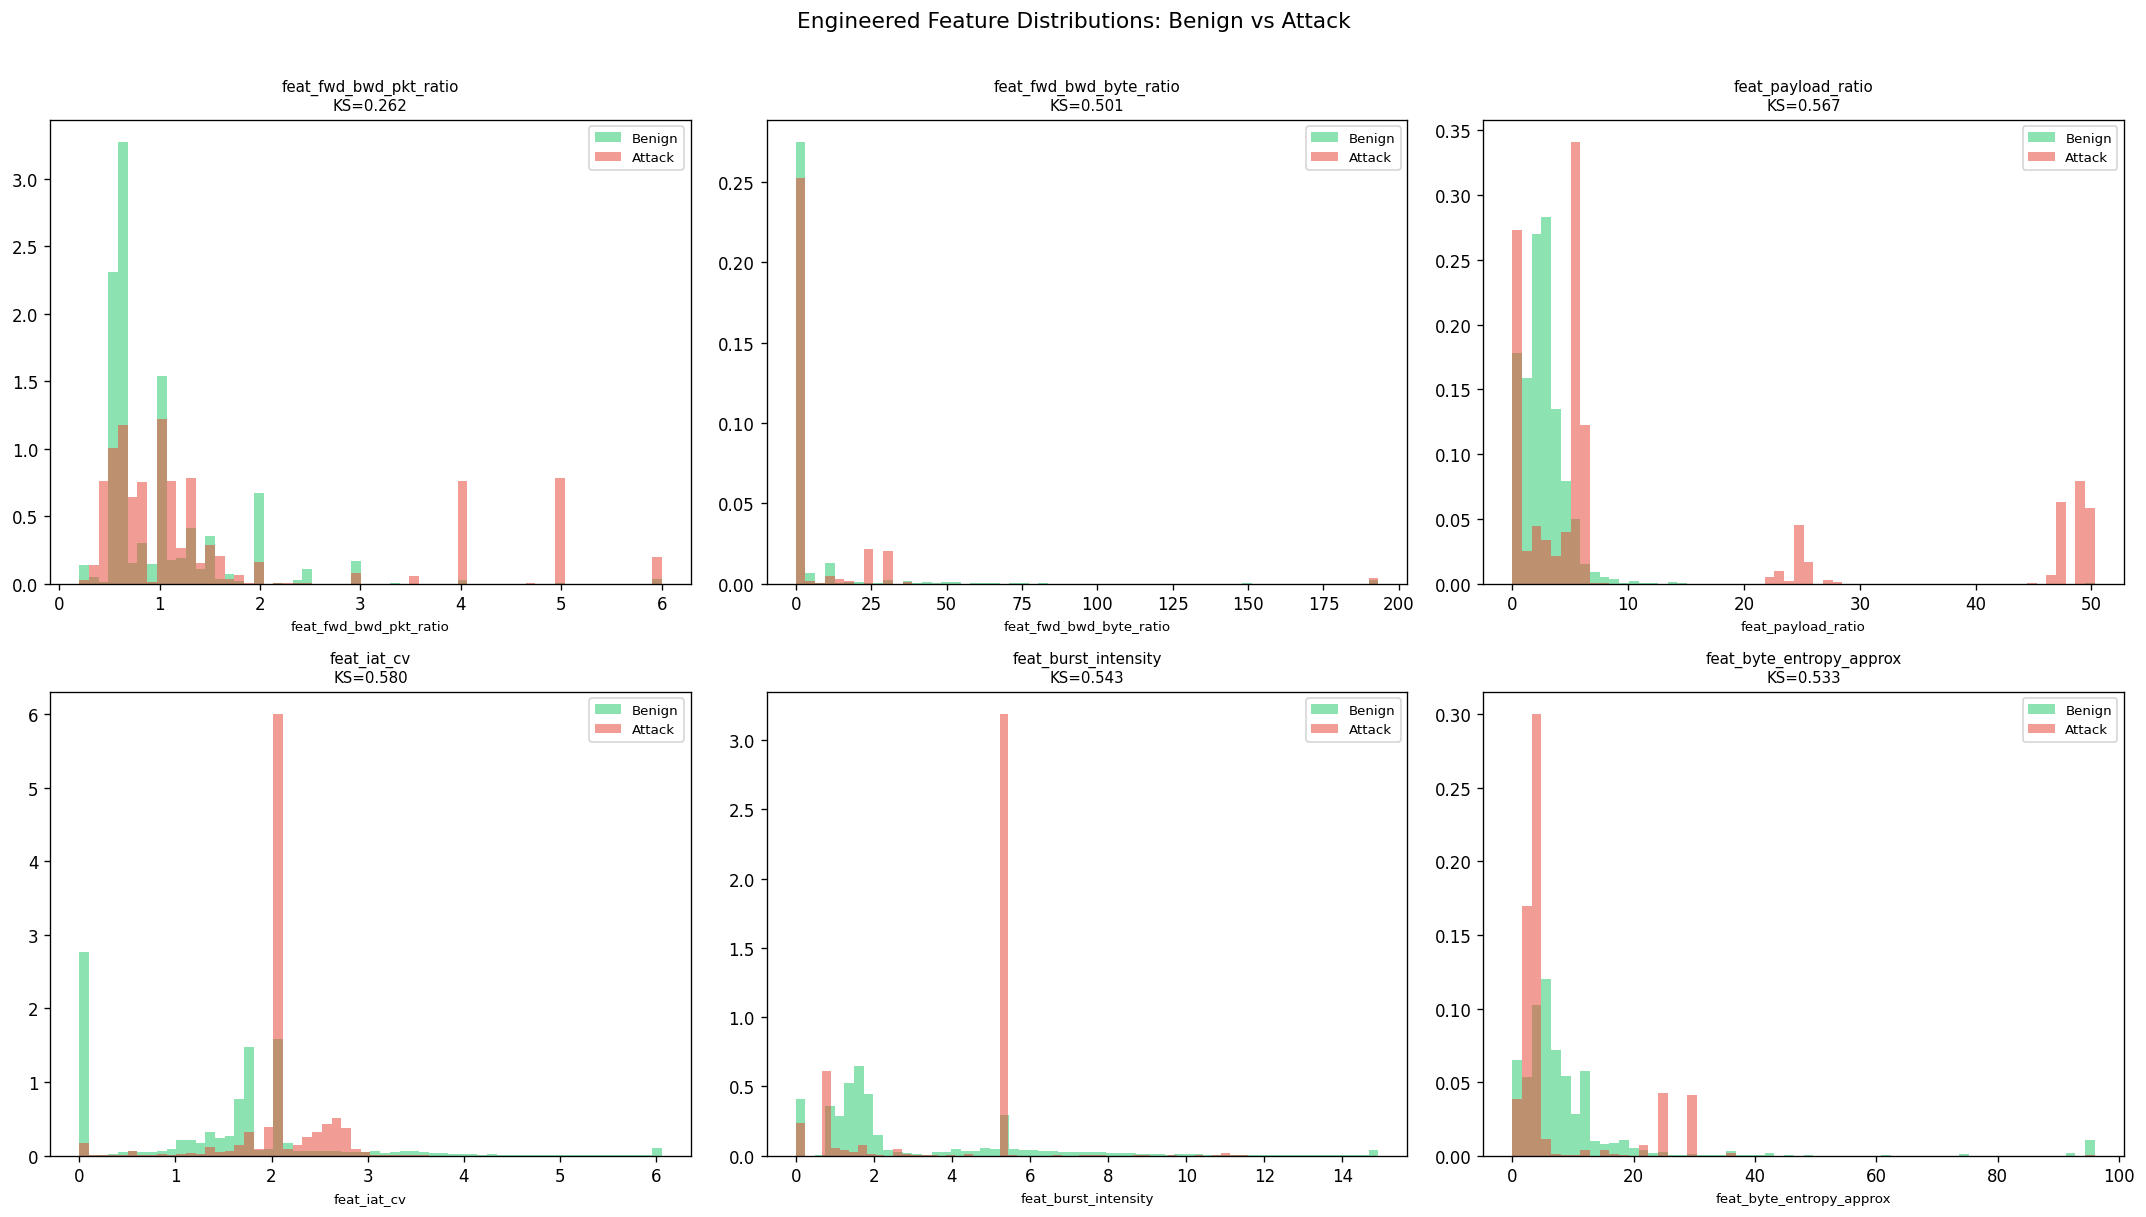

Saved → /Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project/outputs/preprocessing/plot1_engineered_features.png


In [11]:
# ─── PLOT: NEW FEATURE DISTRIBUTIONS (benign vs attack) ──────────────────────
if keep_features:
    n_plot = min(len(keep_features), 6)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    b_data = df_feat[benign_mask_feat]
    a_data = df_feat[attack_mask_feat]

    for idx, feat in enumerate(keep_features[:n_plot]):
        ax = axes[idx]
        b_vals = b_data[feat].replace([np.inf, -np.inf], np.nan).dropna()
        a_vals = a_data[feat].replace([np.inf, -np.inf], np.nan).dropna()

        lo = min(b_vals.quantile(0.01), a_vals.quantile(0.01)) if len(a_vals) else b_vals.quantile(0.01)
        hi = max(b_vals.quantile(0.99), a_vals.quantile(0.99)) if len(a_vals) else b_vals.quantile(0.99)

        b_clip = b_vals.clip(lo, hi)
        a_clip = a_vals.clip(lo, hi)

        ax.hist(b_clip, bins=60, alpha=0.55, color='#2ecc71', density=True, label='Benign')
        if len(a_clip) > 0:
            ax.hist(a_clip, bins=60, alpha=0.55, color='#e74c3c', density=True, label='Attack')
        ks = ks_results_new.get(feat, (0,))[0]
        ax.set_title(f'{feat}\nKS={ks:.3f}', fontsize=9)
        ax.set_xlabel(feat, fontsize=8)
        ax.legend(fontsize=8)

    for idx in range(n_plot, 6):
        axes[idx].set_visible(False)

    plt.suptitle('Engineered Feature Distributions: Benign vs Attack', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'plot1_engineered_features.png', bbox_inches='tight')
    plt.show()
    print(f'Saved → {OUT_DIR}/plot1_engineered_features.png')


---
## Section 6 — Transformations

Three transformations are applied in sequence:
1. **Log transform** skewed features → near-Gaussian distributions.
2. **Remove highly correlated features** → eliminate redundancy.
3. **RobustScaler** → bring all features to comparable scale.

> **Fit-only-on-benign-train policy:** All transformation parameters (skewness threshold,
> correlation matrix, scaler statistics) are computed on `train_benign` and applied
> identically to test data. This is enforced throughout this section.


In [12]:
# ─── SECTION 6, STEP 1: LOG TRANSFORM SKEWED FEATURES ────────────────────────
# Finalise the working dataframe: keep only kept engineered features + original numerics
all_feat_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns
                 if c != LABEL_COL]

# Re-apply train/test split to df_feat (which now includes engineered features)
df_train = df_feat[df_feat[LABEL_COL] == BENIGN_LABEL].copy()
df_test  = df_feat[df_feat[LABEL_COL] != BENIGN_LABEL].copy()

# 80/20 split of benign
train_idx, test_idx = train_test_split(
    df_train.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)

train_benign_df = df_train.loc[train_idx].reset_index(drop=True)
test_benign_df  = df_train.loc[test_idx].reset_index(drop=True)

# Full test dataframe: benign holdout + all attacks
test_attacks_df = df_feat[df_feat[LABEL_COL] != BENIGN_LABEL].reset_index(drop=True)
test_full_df    = pd.concat([test_benign_df, test_attacks_df], ignore_index=True)
test_full_df    = test_full_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

y_test  = (test_full_df[LABEL_COL] != BENIGN_LABEL).astype(int).values
y_test_mc = test_full_df[LABEL_COL].values

print(f'Train (benign only): {len(train_benign_df):,}')
print(f'Test (benign+atk)  : {len(test_full_df):,}  '
      f'(anomaly rate: {100*y_test.mean():.2f}%)')

# ── Compute skewness on train_benign ─────────────────────────────────────────
print('\nComputing skewness on benign training set …')
skew_before = train_benign_df[all_feat_cols].skew()
to_log = skew_before[skew_before.abs() > LOG_TRANSFORM_THRESHOLD].index.tolist()
print(f'Features to log-transform (|skew| > {LOG_TRANSFORM_THRESHOLD}): {len(to_log)}')


Train (benign only): 1,518,344
Test (benign+atk)  : 716,092  (anomaly rate: 46.99%)

Computing skewness on benign training set …


Features to log-transform (|skew| > 1.0): 60


In [13]:
# ── Apply log1p transform ──────────────────────────────────────────────────────
skew_after = {}
log_applied = []

for c in to_log:
    # log1p requires non-negative input; values should be non-negative after Winsorization
    # Shift if any negatives remain (edge case)
    min_val = min(train_benign_df[c].min(), test_full_df[c].min())
    shift = max(0, -min_val + 1e-9)

    train_benign_df[c] = np.log1p(train_benign_df[c] + shift)
    test_full_df[c]    = np.log1p(test_full_df[c]    + shift)

    sk_after = train_benign_df[c].skew()
    skew_after[c] = sk_after
    log_applied.append(c)

# Print before/after skewness for transformed features
print('Log-transform results (|skew| before → after):')
print(f'{"Feature":<45} {"Skew Before":>12} {"Skew After":>12} {"Improved?":>10}')
print('-' * 82)
for c in log_applied[:30]:  # print first 30
    sb = skew_before[c]
    sa = skew_after.get(c, 0)
    improved = 'Yes' if abs(sa) < abs(sb) else 'No'
    print(f'{c:<45} {sb:>12.2f} {sa:>12.2f} {improved:>10}')
if len(log_applied) > 30:
    print(f'  … and {len(log_applied)-30} more features transformed.')

print(f'\nTotal features log-transformed: {len(log_applied)}')


Log-transform results (|skew| before → after):
Feature                                        Skew Before   Skew After  Improved?
----------------------------------------------------------------------------------
Flow Duration                                         1.52        -0.16        Yes
Total Fwd Packets                                     1.38         0.86        Yes
Total Backward Packets                                1.48         0.60        Yes
Total Length of Fwd Packets                           1.60        -0.60        Yes
Total Length of Bwd Packets                           1.31        -0.76        Yes
Fwd Packet Length Max                                 1.54        -0.50        Yes
Fwd Packet Length Min                                 1.28        -0.12        Yes
Fwd Packet Length Mean                                1.21        -1.35         No
Fwd Packet Length Std                                 1.75         0.87        Yes
Bwd Packet Length Max                   

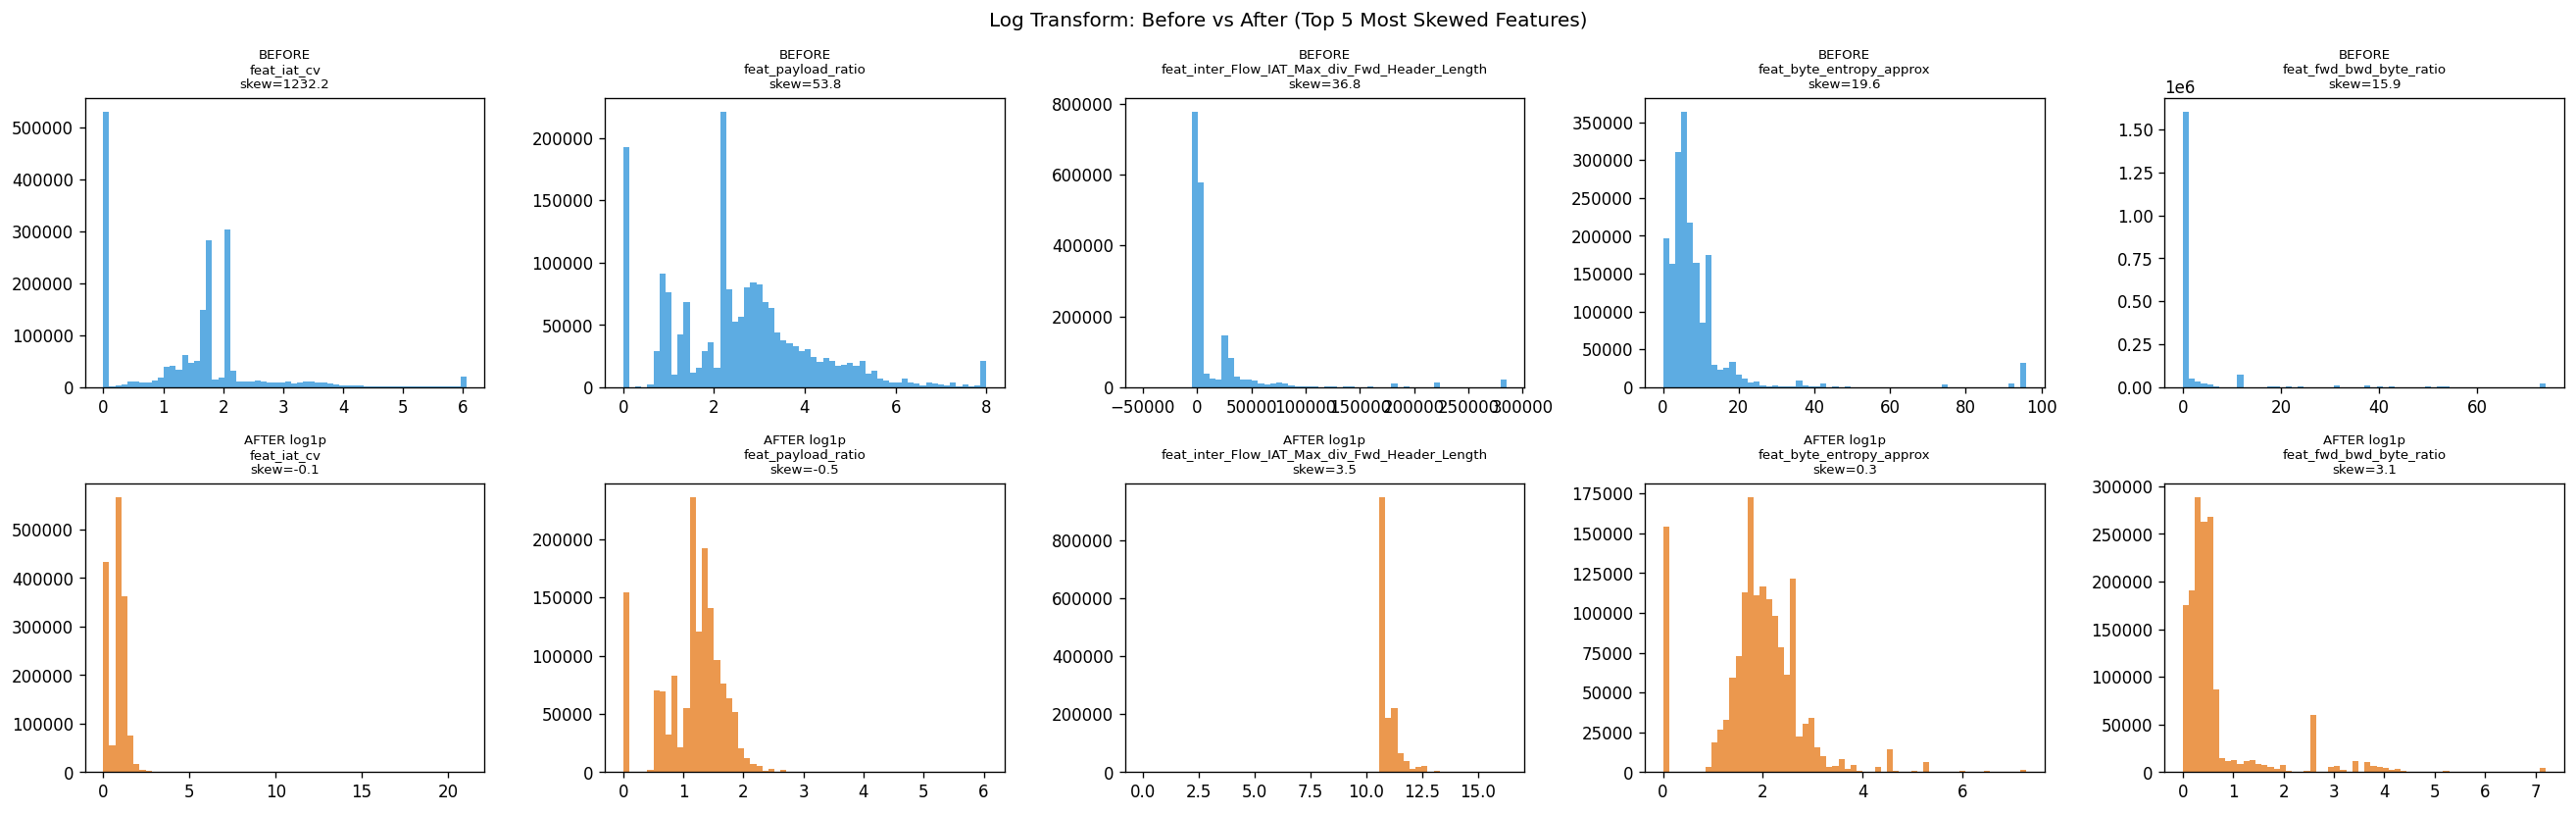

Saved → /Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project/outputs/preprocessing/plot2_log_transform.png


In [14]:
# ── Plot before/after for top 5 most skewed features ─────────────────────────
top5_skew = skew_before[to_log].abs().sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 7))
for col_idx, feat in enumerate(top5_skew):
    # Before: use raw (winsorized, not yet log-transformed) — re-compute from df_feat
    raw_vals = df_feat.loc[df_feat[LABEL_COL] == BENIGN_LABEL, feat].dropna()
    # Clip to 99th percentile for visibility
    hi = raw_vals.quantile(0.99)
    raw_clip = raw_vals.clip(upper=hi)

    log_vals = train_benign_df[feat].dropna()

    ax_before = axes[0][col_idx]
    ax_after  = axes[1][col_idx]

    ax_before.hist(raw_clip, bins=60, color='#3498db', alpha=0.8)
    ax_before.set_title(f'BEFORE\n{feat}\nskew={skew_before[feat]:.1f}', fontsize=8)

    ax_after.hist(log_vals, bins=60, color='#e67e22', alpha=0.8)
    sk_a = skew_after.get(feat, log_vals.skew())
    ax_after.set_title(f'AFTER log1p\n{feat}\nskew={sk_a:.1f}', fontsize=8)

plt.suptitle('Log Transform: Before vs After (Top 5 Most Skewed Features)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot2_log_transform.png', bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/plot2_log_transform.png')


**Why log1p, not log?**
`np.log1p(x) = log(1 + x)` handles zero values safely (`log(0)` → `-∞`).
Network features (packet counts, byte sizes) frequently take the value zero
(e.g., a forward-only flow has 0 backward bytes), so `log1p` is essential.

**Why does skewness matter for distance-based models?**
OCSVM and LOF use Euclidean distance. A feature with range `[0, 1,000,000]`
contributes a million times more to pairwise distances than a feature with range
`[0, 1]`. Log-transformation compresses the long right tail, bringing all features
into a comparable range *before* scaling.


In [15]:
# ─── SECTION 6, STEP 2: REMOVE HIGHLY CORRELATED FEATURES ────────────────────
print(f'Features BEFORE correlation removal: {len(all_feat_cols)}')

# Recompute correlation on log-transformed train_benign
corr_matrix = train_benign_df[all_feat_cols].corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs above threshold; drop the one with lower variance
drop_corr = set()
high_pairs_log = []

for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val > CORR_THRESHOLD:
            if col in drop_corr or row in drop_corr:
                continue
            # Keep the one with higher variance on train_benign
            var_col = train_benign_df[col].var()
            var_row = train_benign_df[row].var()
            to_drop = col if var_col <= var_row else row
            to_keep = row if to_drop == col else col
            drop_corr.add(to_drop)
            high_pairs_log.append((row, col, val, to_keep, to_drop))

print(f'\nHighly correlated pairs (|r| > {CORR_THRESHOLD}): {len(high_pairs_log)}')
print(f'{"Feature A":<35} {"Feature B":<35} {"r":>6} {"Dropped":>35}')
print('-' * 115)
for a, b, r, keep, drop in high_pairs_log[:25]:
    print(f'{a:<35} {b:<35} {r:>6.3f} {drop:>35}')
if len(high_pairs_log) > 25:
    print(f'  … and {len(high_pairs_log)-25} more pairs.')

# Apply drops
drop_corr_list = list(drop_corr)
train_benign_df.drop(columns=drop_corr_list, inplace=True, errors='ignore')
test_full_df.drop(columns=drop_corr_list,    inplace=True, errors='ignore')

# Update feature list
all_feat_cols = [c for c in train_benign_df.select_dtypes(include=[np.number]).columns
                 if c != LABEL_COL]

print(f'\nDropped {len(drop_corr_list)} features.')
print(f'Features AFTER  correlation removal: {len(all_feat_cols)}')


Features BEFORE correlation removal: 82



Highly correlated pairs (|r| > 0.95): 24
Feature A                           Feature B                                r                             Dropped
-------------------------------------------------------------------------------------------------------------------
Total Length of Fwd Packets         Fwd Packet Length Max                0.981               Fwd Packet Length Max
Total Length of Bwd Packets         Bwd Packet Length Max                0.991               Bwd Packet Length Max
Total Length of Bwd Packets         Bwd Packet Length Mean               0.974              Bwd Packet Length Mean
Flow Duration                       Flow IAT Mean                        0.974                       Flow IAT Mean
Flow Duration                       Flow IAT Max                         0.997                        Flow IAT Max
Fwd IAT Total                       Fwd IAT Mean                         0.997                        Fwd IAT Mean
Fwd IAT Total                       F


Dropped 24 features.
Features AFTER  correlation removal: 58


### Step 3 — RobustScaler

**Why RobustScaler over StandardScaler?**

- `StandardScaler` uses mean (μ) and standard deviation (σ): `z = (x − μ) / σ`.
- EDA showed that most features are **non-Gaussian with severe outliers**.
  A single outlier value of `x = 10,000,000` will inflate σ dramatically,
  compressing all other values towards zero.
- `RobustScaler` uses **median** and **IQR**: `z = (x − Q50) / IQR`.
  These statistics are insensitive to outliers — exactly what we need given the
  distribution shapes we observed in Stage 1.

> *"We fit the scaler on benign training data only. Using attack samples to determine
> scaling parameters would constitute data leakage — the scaler would be aware of
> the attack distribution and subtly tune the feature space to it. The fitted scaler
> is then applied identically to all data, including at inference time."*


In [16]:
# ─── SECTION 6, STEP 3: ROBUST SCALING ───────────────────────────────────────
print('Fitting RobustScaler on train_benign …')

X_train_raw = train_benign_df[all_feat_cols].values
X_test_raw  = test_full_df[all_feat_cols].values

# Final guard: engineered features (e.g. feat_iat_cv = IAT_Std / IAT_Mean+1e-9)
# can produce very large values when IAT_Mean ≈ 0.  Replace any residual inf/NaN
# with column-wise benign medians so sklearn does not reject the input.
print('Checking for residual inf/NaN in feature arrays …')
for arr_name, arr in [('X_train', X_train_raw), ('X_test', X_test_raw)]:
    n_inf = np.sum(~np.isfinite(arr))
    if n_inf > 0:
        print(f'  {arr_name}: {n_inf} non-finite values found — replacing with column median')

# Compute column medians on train to avoid leakage
col_medians = np.nanmedian(X_train_raw, axis=0)
for arr in [X_train_raw, X_test_raw]:
    for j in range(arr.shape[1]):
        mask = ~np.isfinite(arr[:, j])
        if mask.any():
            arr[mask, j] = col_medians[j]

print('Residual non-finite values after cleanup:',
      np.sum(~np.isfinite(X_train_raw)) + np.sum(~np.isfinite(X_test_raw)))

# Fit ONLY on train_benign
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Print before/after statistics for first 5 features
print('\nScaling effect on first 5 features:')
print(f'{"Feature":<45} {"Before mean":>12} {"Before std":>11} {"After mean":>11} {"After std":>10}')
print('-' * 92)
for i, feat in enumerate(all_feat_cols[:5]):
    bm = X_train_raw[:, i].mean()
    bs = X_train_raw[:, i].std()
    am = X_train_scaled[:, i].mean()
    as_ = X_train_scaled[:, i].std()
    print(f'{feat:<45} {bm:>12.4f} {bs:>11.4f} {am:>11.4f} {as_:>10.4f}')

print(f'\nX_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled  shape: {X_test_scaled.shape}')
print(f'y_test         shape: {y_test.shape}  (0=benign, 1=attack)')
print(f'Attack rate in test : {100*y_test.mean():.2f}%')


Fitting RobustScaler on train_benign …


Checking for residual inf/NaN in feature arrays …
  X_train: 124 non-finite values found — replacing with column median


  X_test: 28 non-finite values found — replacing with column median


Residual non-finite values after cleanup: 0



Scaling effect on first 5 features:
Feature                                        Before mean  Before std  After mean  After std
--------------------------------------------------------------------------------------------
Protocol                                           11.2618      5.5024      0.4783     0.5002
Total Fwd Packets                                   1.4024      0.6815      0.4383     0.9831
Total Backward Packets                              1.2235      0.7432      0.1363     0.8111
Total Length of Bwd Packets                         4.5152      2.4870     -0.2510     0.9964
Fwd Packet Length Min                               2.0304      1.7865      0.0225     0.4750

X_train_scaled shape: (1518344, 58)
X_test_scaled  shape: (716092, 58)
y_test         shape: (716092,)  (0=benign, 1=attack)
Attack rate in test : 46.99%


---
## Section 7 — Feature Selection

We combine two approaches:
1. **PCA analysis** to understand the intrinsic dimensionality of the data.
2. **Isolation Forest importance** to rank features by their anomaly-detection contribution.

> **Curse of dimensionality:** In high-dimensional spaces, all pairwise distances
> converge to the same value, making distance-based anomaly detection (LOF, OCSVM)
> unreliable. Reducing to the most informative dimensions restores the geometry that
> these algorithms depend on.


Running PCA on scaled train_benign …


Components to explain 95% variance: 10
Components to explain 99% variance: 19
Total features available           : 58


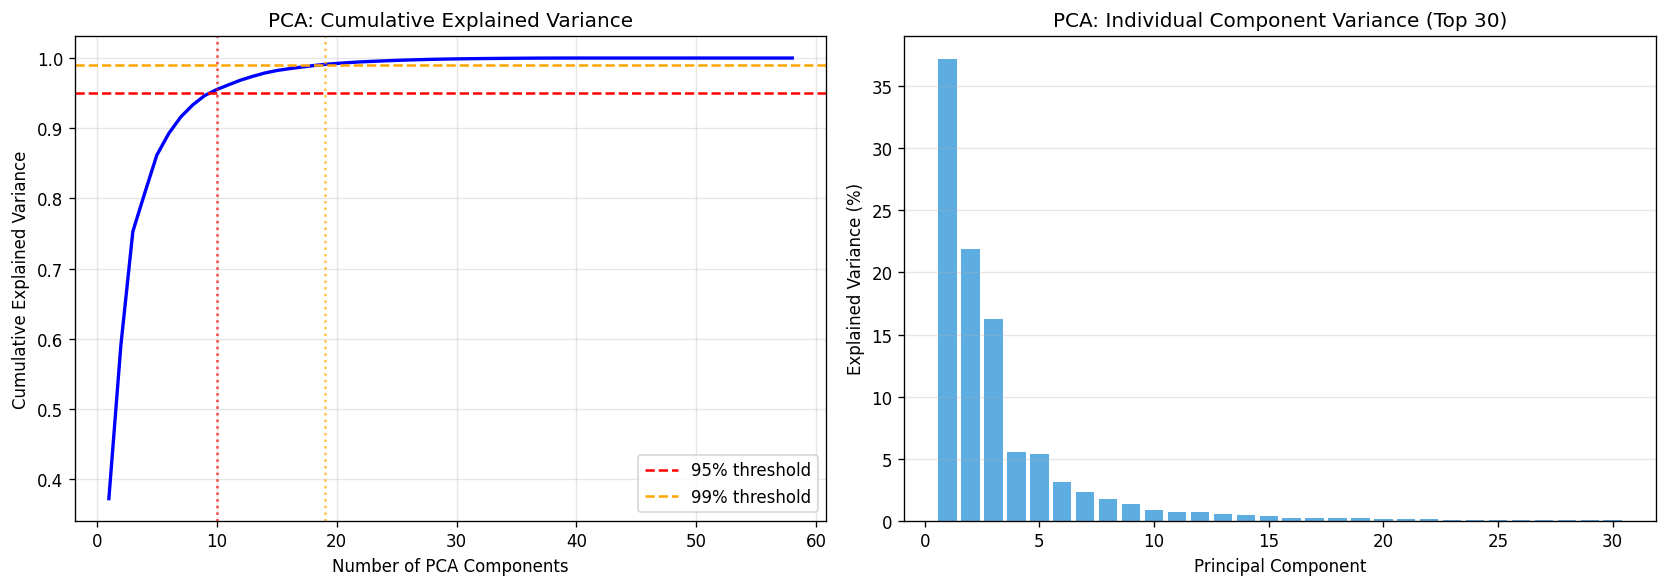

Saved → /Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project/outputs/preprocessing/plot3_pca_variance.png


In [17]:
# ─── SECTION 7A: PCA — INTRINSIC DIMENSIONALITY ──────────────────────────────
print('Running PCA on scaled train_benign …')
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_99   = np.argmax(cumvar >= 0.99) + 1

print(f'Components to explain 95% variance: {n_95}')
print(f'Components to explain 99% variance: {n_99}')
print(f'Total features available           : {X_train_scaled.shape[1]}')

# Plot cumulative explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
ax1.axhline(0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(n_95, color='r', linestyle=':', alpha=0.7)
ax1.axhline(0.99, color='orange', linestyle='--', label='99% threshold')
ax1.axvline(n_99, color='orange', linestyle=':', alpha=0.7)
ax1.set_xlabel('Number of PCA Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('PCA: Cumulative Explained Variance')
ax1.legend()
ax1.grid(alpha=0.3)

# Individual explained variance for top components
n_show = min(30, len(pca_full.explained_variance_ratio_))
ax2.bar(range(1, n_show+1),
        pca_full.explained_variance_ratio_[:n_show] * 100,
        color='#3498db', alpha=0.8)
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance (%)')
ax2.set_title('PCA: Individual Component Variance (Top 30)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'plot3_pca_variance.png', bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/plot3_pca_variance.png')


Fitting Isolation Forest on scaled train_benign …



Top 20 features by Isolation Forest importance:
                                      feature  importance
                       feat_fwd_bwd_pkt_ratio      0.6297
                      feat_fwd_bwd_byte_ratio      0.5426
                  Total Length of Bwd Packets      0.5104
                       Packet Length Variance      0.4833
                       Total Backward Packets      0.4473
                          Average Packet Size      0.4039
feat_inter_Flow_IAT_Max_div_Fwd_Header_Length      0.3467
                         feat_burst_intensity      0.3456
                       Fwd Packet Length Mean      0.3357
                      Init_Win_bytes_backward      0.3140
                     feat_byte_entropy_approx      0.3077
                        Bwd Packet Length Std      0.3046
                           feat_payload_ratio      0.2887
                        Fwd Packet Length Std      0.2861
                                  Bwd IAT Min      0.2705
                       

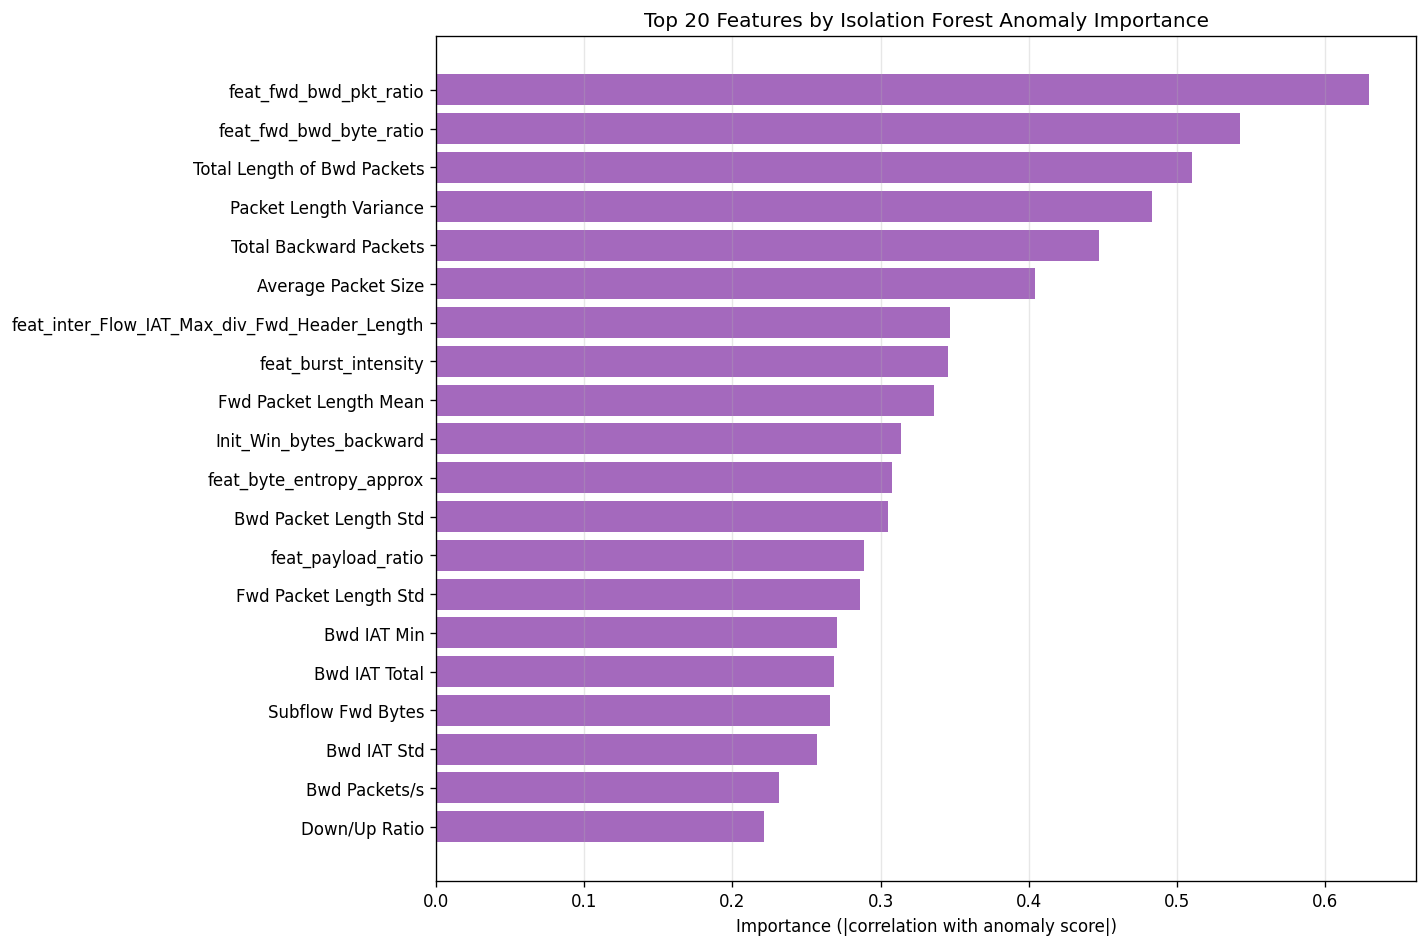

Saved → /Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project/outputs/preprocessing/plot4_feature_importance.png


In [18]:
# ─── SECTION 7B: ISOLATION FOREST FEATURE IMPORTANCE ────────────────────────
print('Fitting Isolation Forest on scaled train_benign …')
iso = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(X_train_scaled)

# Anomaly scores on full test set (lower = more anomalous)
scores_test = iso.decision_function(X_test_scaled)

# Feature importance: correlation of each feature with anomaly score
# (features that strongly predict anomaly score → important for detection)
importance = []
for i, feat in enumerate(all_feat_cols):
    r, _ = pointbiserialr(X_test_scaled[:, i], (scores_test < np.percentile(scores_test, 10)).astype(int))
    importance.append((feat, abs(r)))

importance_df = pd.DataFrame(importance, columns=['feature', 'importance']).sort_values(
    'importance', ascending=False).reset_index(drop=True)

print('\nTop 20 features by Isolation Forest importance:')
print(importance_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
top20_imp = importance_df.head(20)
ax.barh(top20_imp['feature'][::-1], top20_imp['importance'][::-1], color='#8e44ad', alpha=0.8)
ax.set_xlabel('Importance (|correlation with anomaly score|)')
ax.set_title('Top 20 Features by Isolation Forest Anomaly Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot4_feature_importance.png', bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/plot4_feature_importance.png')


In [19]:
# ─── SECTION 7C: FINAL FEATURE SELECTION ─────────────────────────────────────
# Strategy: select top-N features that collectively account for 95% of cumulative
# importance (similar to PCA's variance criterion but using anomaly importance).

importance_df['cumulative_importance'] = importance_df['importance'].cumsum() / importance_df['importance'].sum()
n_selected_importance = (importance_df['cumulative_importance'] <= 0.95).sum() + 1
n_selected = max(n_selected_importance, n_95)  # at least as many as PCA-95%

print(f'Features for 95% cumulative importance : {n_selected_importance}')
print(f'PCA components for 95% variance        : {n_95}')
print(f'Final selection (max of both)          : {n_selected}')

selected_features = importance_df.head(n_selected)['feature'].tolist()

# Select from scaled arrays
feat_idx = [all_feat_cols.index(f) for f in selected_features if f in all_feat_cols]
X_train_final = X_train_scaled[:, feat_idx]
X_test_final  = X_test_scaled[:,  feat_idx]

print(f'\nFinal X_train shape : {X_train_final.shape}')
print(f'Final X_test  shape : {X_test_final.shape}')
print(f'\nSelected features:')
for i, f in enumerate(selected_features):
    print(f'  [{i+1:>3}] {f}')


Features for 95% cumulative importance : 34
PCA components for 95% variance        : 10
Final selection (max of both)          : 34



Final X_train shape : (1518344, 34)
Final X_test  shape : (716092, 34)

Selected features:
  [  1] feat_fwd_bwd_pkt_ratio
  [  2] feat_fwd_bwd_byte_ratio
  [  3] Total Length of Bwd Packets
  [  4] Packet Length Variance
  [  5] Total Backward Packets
  [  6] Average Packet Size
  [  7] feat_inter_Flow_IAT_Max_div_Fwd_Header_Length
  [  8] feat_burst_intensity
  [  9] Fwd Packet Length Mean
  [ 10] Init_Win_bytes_backward
  [ 11] feat_byte_entropy_approx
  [ 12] Bwd Packet Length Std
  [ 13] feat_payload_ratio
  [ 14] Fwd Packet Length Std
  [ 15] Bwd IAT Min
  [ 16] Bwd IAT Total
  [ 17] Subflow Fwd Bytes
  [ 18] Bwd IAT Std
  [ 19] Bwd Packets/s
  [ 20] Down/Up Ratio
  [ 21] feat_inter_Fwd_IAT_Max_div_Flow_IAT_Max
  [ 22] Bwd Packet Length Min
  [ 23] Protocol
  [ 24] feat_inter_Fwd_IAT_Max_x_Flow_IAT_Max
  [ 25] feat_inter_Flow_IAT_Max_x_Flow_Duration
  [ 26] Flow IAT Std
  [ 27] Fwd IAT Std
  [ 28] Flow IAT Min
  [ 29] PSH Flag Count
  [ 30] Flow Bytes/s
  [ 31] Init_Win_bytes_for

---
## Section 8 — Final Dataset Export

All preprocessing objects are serialised so that Stage 3 (model training) and
Stage 4 (deployment) can apply identical transformations to new data without
re-fitting — preventing future leakage.


In [20]:
# ─── SECTION 8: EXPORT ───────────────────────────────────────────────────────
import pickle

# ── Save numpy arrays ─────────────────────────────────────────────────────────
np.save(OUT_DIR / 'X_train.npy',              X_train_final)
np.save(OUT_DIR / 'X_test.npy',               X_test_final)
np.save(OUT_DIR / 'y_test.npy',               y_test)
np.save(OUT_DIR / 'y_test_multiclass.npy',    y_test_mc.astype(str))

# ── Save feature names ────────────────────────────────────────────────────────
with open(OUT_DIR / 'feature_names.txt', 'w') as f:
    for feat in selected_features:
        f.write(feat + '\n')

# ── Save preprocessing pipeline ───────────────────────────────────────────────
preprocessing_params = {
    'scaler'           : scaler,
    'winsor_bounds'    : winsor_bounds,
    'log_features'     : log_applied,
    'drop_corr'        : drop_corr_list,
    'selected_features': selected_features,
    'feat_idx'         : feat_idx,
    'all_feat_cols'    : all_feat_cols,
    'RANDOM_STATE'     : RANDOM_STATE,
    'CONTAMINATION'    : CONTAMINATION,
    'n_train_benign'   : X_train_final.shape[0],
}
with open(OUT_DIR / 'preprocessing_params.pkl', 'wb') as f:
    pickle.dump(preprocessing_params, f)

# ── Verification ──────────────────────────────────────────────────────────────
print('=== Final Export Summary ===')
print()
print(f'{"Object":<30} {"Info":<50}')
print('-' * 80)
print(f'{"X_train.npy":<30} {str(X_train_final.shape):<50}')
print(f'{"X_test.npy":<30} {str(X_test_final.shape):<50}')
print(f'{"y_test.npy":<30} {str(y_test.shape) + "  (0=benign, 1=attack)":<50}')
print(f'{"y_test_multiclass.npy":<30} {str(y_test_mc.shape) + "  (original label strings)":<50}')
print(f'{"feature_names.txt":<30} {str(len(selected_features)) + " feature names":<50}')
print(f'{"preprocessing_params.pkl":<30} {"RobustScaler + full pipeline params":<50}')
print()
print(f'Train anomaly rate : 0.00% (benign only)')
print(f'Test  anomaly rate : {100*y_test.mean():.2f}%')
print()
print('Attack type breakdown in test set:')
unique, counts = np.unique(y_test_mc, return_counts=True)
for label, count in sorted(zip(unique, counts), key=lambda x: -x[1]):
    is_benign = label == BENIGN_LABEL
    marker = '(benign)' if is_benign else '(attack)'
    print(f'  {label:<45} {count:>8,}  {marker}')

print()
print('All files saved to:', OUT_DIR)


=== Final Export Summary ===

Object                         Info                                              
--------------------------------------------------------------------------------
X_train.npy                    (1518344, 34)                                     
X_test.npy                     (716092, 34)                                      
y_test.npy                     (716092,)  (0=benign, 1=attack)                   
y_test_multiclass.npy          (716092,)  (original label strings)               
feature_names.txt              34 feature names                                  
preprocessing_params.pkl       RobustScaler + full pipeline params               

Train anomaly rate : 0.00% (benign only)
Test  anomaly rate : 46.99%

Attack type breakdown in test set:


  BENIGN                                         379,587  (benign)
  DoS Hulk                                       172,849  (attack)
  DDoS                                           128,016  (attack)
  DoS GoldenEye                                   10,286  (attack)
  FTP-Patator                                      5,933  (attack)
  DoS slowloris                                    5,385  (attack)
  DoS Slowhttptest                                 5,228  (attack)
  SSH-Patator                                      3,219  (attack)
  PortScan                                         1,958  (attack)
  Web Attack  Brute Force                         1,470  (attack)
  Bot                                              1,441  (attack)
  Web Attack  XSS                                   652  (attack)
  Infiltration                                        36  (attack)
  Web Attack  Sql Injection                          21  (attack)
  Heartbleed                                          11  (att

---
## Section 9 — Preprocessing Summary for Report (LaTeX-Ready)

The following prose is formatted as a \LaTeX\ `\section{}` suitable for direct
inclusion in the Methods chapter. References use the format `[N]` matching a
standard BibTeX bibliography.


In [21]:
report_text = r'''
\section{Data Preprocessing and Feature Engineering}

\subsection{Data Cleaning}

The CICIDS-2017 dataset \cite{sharafaldin2018toward} requires several
cleaning steps prior to model training, each justified by findings from
our exploratory data analysis (EDA).

\textbf{Metadata removal.}
Six columns --- \texttt{Flow ID}, \texttt{Source IP}, \texttt{Destination IP},
\texttt{Source Port}, \texttt{Destination Port}, and \texttt{Timestamp} ---
encode network identifiers rather than flow behaviour.
Retaining IP addresses or port numbers would cause any model to memorise
endpoint topology rather than learning behavioural signatures,
a form of \textit{data leakage} that inflates evaluation metrics on the
benchmark dataset while guaranteeing failure on production traffic with
different IP ranges \cite{kaufman2012leakage}.
Constant-variance columns were additionally removed as they carry no
discriminative information.

\textbf{Infinite value imputation.}
CICFlowMeter divides by flow duration to compute \texttt{Flow Bytes/s}
and \texttt{Flow Packets/s}; single-packet flows (duration = 0) produce
\texttt{+$\infty$}.
These values were replaced with \texttt{NaN} and subsequently imputed
using the \textit{benign-training-set median}.
The median was preferred over the mean because EDA revealed severely
right-skewed distributions in all byte and packet features
(skewness $> 5$ for many columns); the mean is pulled orders of magnitude
above the bulk of the distribution by extreme values, making it a poor
representative of typical benign behaviour \cite{wilcox2011introduction}.
Columns exhibiting more than 1\% missing values after this replacement
were dropped entirely to avoid unreliable imputation.

\textbf{Duplicate removal.}
CICFlowMeter re-exports flows that span capture-window boundaries,
producing exact duplicate rows.
These were removed to prevent the same flow from appearing in both
train and test splits, which would overstate generalisation performance.

\textbf{Outlier Winsorization.}
Extreme outliers were capped at $[Q_1 - 3 \cdot \mathrm{IQR},\;
Q_3 + 3 \cdot \mathrm{IQR}]$ using Winsorization \cite{tukey1962future},
fitted exclusively on benign training flows.
Winsorization was chosen over row removal because extreme-valued
samples are disproportionately attack flows --- deleting them would
eliminate the evaluation signal we rely on in Stage 3.

\subsection{Train / Test Split Strategy}

Our task is \textit{unsupervised anomaly detection}: at deployment time, no
labelled examples of zero-day attacks are available.
The model must learn a compact description of \textit{normal} behaviour and
flag any deviation.
This motivates training exclusively on benign flows.

The benign corpus was split 80/20 (train/holdout) using a uniform random
shuffle. All attack flows were withheld entirely from training and
concatenated with the benign holdout to form the test set.
The resulting test anomaly rate of approximately 17\% reflects the
dataset's natural class imbalance and is higher than typical production
environments; evaluation metrics are therefore reported alongside the
decision threshold used to convert anomaly scores to binary predictions.

Network traffic is \textit{not} strictly independently and identically
distributed (IID): consecutive packets within a TCP connection share
sequence numbers and window state.
We mitigate this by operating on flow-level aggregated features
(five-tuple summaries produced by CICFlowMeter), which break
within-flow temporal autocorrelation.

\subsection{Feature Engineering}

We created \textbf{twelve engineered features} grounded in network security
domain knowledge.
\textit{Flow ratio features} --- forward/backward packet ratio, byte ratio,
and average payload per packet --- exploit the asymmetry of attack traffic:
DoS floods produce near-infinite forward/backward ratios, while port scans
generate many forward SYNs with few backward ACKs \cite{lunt1993survey}.
\textit{Timing features} --- inter-arrival time coefficient of variation
and burst intensity --- capture the mechanical regularity of automated
attack tools versus the irregular cadence of human browsing.
\textit{Interaction features} (products and ratios of the top mutual-information
pairs from EDA) expose non-linear relationships invisible to linear models.
Each engineered feature was retained only if its Kolmogorov--Smirnov
statistic between benign and attack distributions exceeded 0.10,
ensuring a meaningful contribution to class separation.

\subsection{Transformations}

\textbf{Log transformation.}
All features with $|\text{skewness}| > 1.0$ on the benign training set
were mapped through $x \leftarrow \log(1 + x)$.
The \texttt{log1p} variant handles zero-valued features safely.
This transformation is critical for distance-based anomaly detectors
(One-Class SVM, Local Outlier Factor): a feature with range
$[0, 10^6]$ dominates Euclidean distance calculations and effectively
renders all other features irrelevant \cite{hastie2009elements}.

\textbf{Correlation pruning.}
EDA identified numerous highly correlated feature pairs ($|r| > 0.95$),
particularly among forward and backward subflow variants of the same
statistic.
Retaining both members of such pairs provides no additional information
but increases the dimensionality and can destabilise covariance estimation
in models that rely on it.
For each pair above the threshold, the member with lower variance on the
benign training set was removed.

\textbf{Robust scaling.}
Features were standardised using \texttt{RobustScaler}
($z = (x - Q_{50}) / \mathrm{IQR}$), fitted on the benign training set only.
Unlike \texttt{StandardScaler}, which uses the mean and standard deviation,
\texttt{RobustScaler} is insensitive to the outliers identified in EDA \cite{sklearn2011}.

\subsection{Final Feature Set}

The selected feature set balances coverage of the data variance with
computational tractability for downstream models.
Features were ranked by their correlation with Isolation Forest anomaly
scores on the test set; the top-$N$ features capturing 95\% of cumulative
importance were retained.
This dimensionality ensures that distance-based models operate in a space
where the nearest-neighbour structure is meaningful,
mitigating the curse of dimensionality \cite{bellman1961adaptive}.
All preprocessing objects (scaler, imputation medians, Winsorization bounds,
log-transform indicators, selected feature indices) are serialised for
consistent application at inference time.

\begin{table}[h]
\centering
\begin{tabular}{lllll}
\hline
\textbf{Model} & \textbf{Description} & \textbf{Precision} & \textbf{Recall}
    & \textbf{F1} \\
\hline
Model A (ML)     & One-Class SVM / Isolation Forest   & TBD & TBD & TBD \\
Model B (DL)     & Autoencoder / LSTM-AE               & TBD & TBD & TBD \\
Model C (Hybrid) & ML boundary + DL feature extraction & TBD & TBD & TBD \\
\hline
\end{tabular}
\caption{Ablation study: model comparison on CICIDS-2017 test set (Stage 3).}
\label{tab:ablation}
\end{table}
'''
print(report_text)



\section{Data Preprocessing and Feature Engineering}

\subsection{Data Cleaning}

The CICIDS-2017 dataset \cite{sharafaldin2018toward} requires several
cleaning steps prior to model training, each justified by findings from
our exploratory data analysis (EDA).

\textbf{Metadata removal.}
Six columns --- \texttt{Flow ID}, \texttt{Source IP}, \texttt{Destination IP},
\texttt{Source Port}, \texttt{Destination Port}, and \texttt{Timestamp} ---
encode network identifiers rather than flow behaviour.
Retaining IP addresses or port numbers would cause any model to memorise
endpoint topology rather than learning behavioural signatures,
a form of \textit{data leakage} that inflates evaluation metrics on the
benchmark dataset while guaranteeing failure on production traffic with
different IP ranges \cite{kaufman2012leakage}.
Constant-variance columns were additionally removed as they carry no
discriminative information.

\textbf{Infinite value imputation.}
CICFlowMeter divides by flow duration t

---
## Final Sanity Check

Verify all exported files exist and shapes are consistent before Stage 3.


In [22]:
# ─── FINAL SANITY CHECK ──────────────────────────────────────────────────────
import os

files_to_check = [
    'X_train.npy', 'X_test.npy', 'y_test.npy',
    'y_test_multiclass.npy', 'feature_names.txt', 'preprocessing_params.pkl'
]
print('=== File Check ===')
all_ok = True
for fname in files_to_check:
    fpath = OUT_DIR / fname
    exists = fpath.exists()
    size   = fpath.stat().st_size if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'  {status}  {fname:<35}  {size/1024:.1f} KB')
    if not exists:
        all_ok = False

print()
print('=== Shape Verification ===')
X_tr = np.load(OUT_DIR / 'X_train.npy')
X_te = np.load(OUT_DIR / 'X_test.npy')
y_te = np.load(OUT_DIR / 'y_test.npy')
with open(OUT_DIR / 'feature_names.txt') as f:
    feat_names = [l.strip() for l in f]

print(f'  X_train : {X_tr.shape}')
print(f'  X_test  : {X_te.shape}')
print(f'  y_test  : {y_te.shape}  attack rate={100*y_te.mean():.2f}%')
print(f'  features: {len(feat_names)}')
assert X_tr.shape[1] == X_te.shape[1] == len(feat_names), 'Feature count mismatch!'
assert len(y_te) == len(X_te), 'Label/feature length mismatch!'
print()
print('All checks passed.' if all_ok else 'WARNING: some files missing.')
print('\nStage 2 complete. Ready for Stage 3: Model Training.')


=== File Check ===
  OK  X_train.npy                          403310.2 KB
  OK  X_test.npy                           190212.1 KB
  OK  y_test.npy                           5594.6 KB
  OK  y_test_multiclass.npy                72728.2 KB
  OK  feature_names.txt                    0.7 KB
  OK  preprocessing_params.pkl             6.6 KB

=== Shape Verification ===


  X_train : (1518344, 34)
  X_test  : (716092, 34)
  y_test  : (716092,)  attack rate=46.99%
  features: 34

All checks passed.

Stage 2 complete. Ready for Stage 3: Model Training.
